# Lead-Lag Analysis

This notebook checks whether VIX and WTI can act as early warning signals for vessel-value moves — that is, whether they lead vessel returns rather than just moving alongside them.

A positive lag means the indicator moves before the vessel return: lag 0 is the same month, lag 1 means the indicator leads by a month, lag 3 by three months, and so on. Pearson correlations and p-values are calculated across lags from 0 to 12 months.

In [7]:
from src.lead_lag import (
    build_lead_lag_table,
    get_best_lag,
    plot_combined_lead_lag,
)

In [8]:
lead_lag_results = build_lead_lag_table(max_lag=12)

lead_lag_results.head()

,feature,lag_months,correlation,p_value,observations
0,vix_level,0,-0.075139,0.299014,193
1,vix_level,1,-0.067971,0.348878,192
2,vix_level,2,-0.127900,0.077857,191
3,vix_level,3,-0.081471,0.263804,190
4,vix_level,4,-0.048635,0.506324,189


In [9]:
lead_lag_results

,feature,lag_months,correlation,p_value,observations
0,vix_level,0,-0.075139,0.299014,193
1,vix_level,1,-0.067971,0.348878,192
2,vix_level,2,-0.127900,0.077857,191
3,vix_level,3,-0.081471,0.263804,190
4,vix_level,4,-0.048635,0.506324,189
5,vix_level,5,-0.031627,0.666566,188
6,vix_level,6,-0.080354,0.274294,187
7,vix_level,7,-0.060559,0.411587,186
8,vix_level,8,0.020757,0.779141,185
9,vix_level,9,0.042646,0.565426,184


## Best-Lag Results

The strongest lagged relationship for each variable is picked out using absolute Pearson correlation. Significance is judged at the 5% level, with results between 5–10% treated as marginal rather than conclusive.

In [10]:
selected_features = [
    "vix_level",
    "vix_return",
    "wti_return",
]

best_lag_rows = []

for feature in selected_features:
    best_result, is_significant = get_best_lag(
        result_df=lead_lag_results,
        feature_name=feature,
    )

    best_lag_rows.append(
        {
            "feature": feature,
            "best_lag": int(best_result["lag_months"]),
            "correlation": best_result["correlation"],
            "p_value": best_result["p_value"],
            "observations": int(best_result["observations"]),
            "significant_at_5pct": is_significant,
        }
    )

In [11]:
import pandas as pd

best_lag_summary = pd.DataFrame(best_lag_rows)

best_lag_summary

,feature,best_lag,correlation,p_value,observations,significant_at_5pct
0,vix_level,2,-0.127900,0.077857,191,False
1,vix_return,7,-0.092990,0.206806,186,False
2,wti_return,3,0.155937,0.031681,190,True


## Lead-Lag Correlation Curves

This chart compares how VIX level and WTI returns correlate with vessel returns across different lags. VIX return isn't shown here — none of its lags came close to a meaningful or significant relationship.

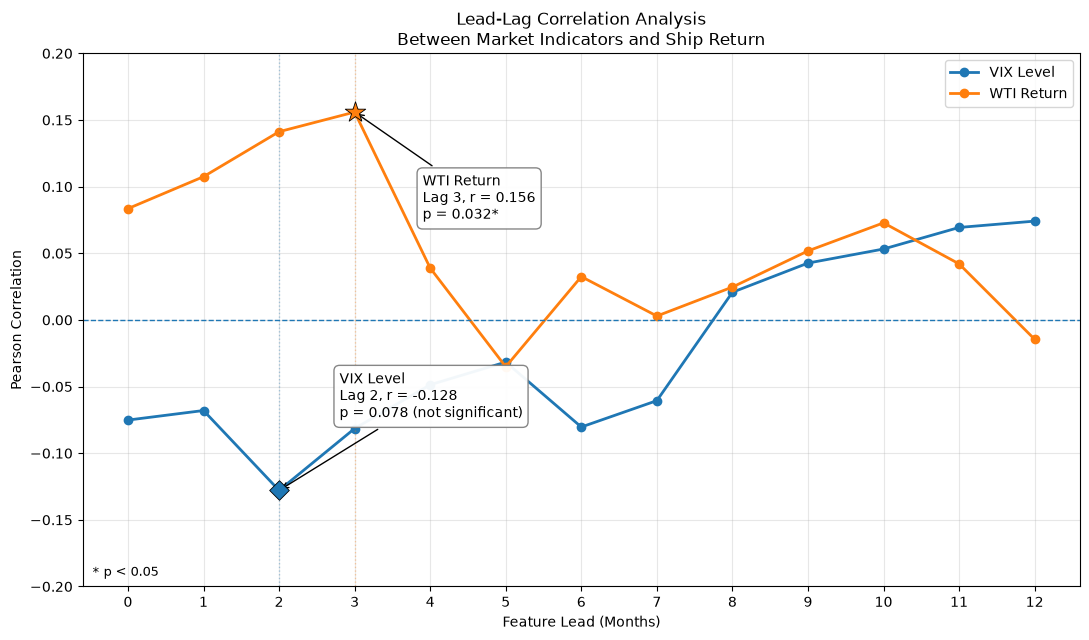

In [12]:
plot_combined_lead_lag(
    result_df=lead_lag_results,
    feature_names=[
        "vix_level",
        "wti_return",
    ],
)

## Key Findings

WTI returns lagged by three months show a statistically significant positive relationship with vessel returns (correlation 0.156, p = 0.032) — early evidence that oil-price moves might carry information about vessel values roughly a quarter ahead.

VIX level's strongest relationship comes at a two-month lag (correlation -0.128, p = 0.078). That's not significant at the 5% level, only marginal at 10%, so it's worth carrying forward as a candidate rather than treating it as confirmed.

VIX returns, meanwhile, don't show a significant relationship at any tested lag, so they're dropped from the regression phase.

## Business Interpretation

WTI returns look like the stronger early-warning candidate here compared to VIX. That's plausible from a ship-finance angle too — oil prices tend to reflect shifts in global economic activity and shipping-market conditions before those changes fully show up in vessel valuations.

That said, the relationship is still modest, and correlation on its own doesn't establish predictive power or causality. The next step is regression, to see whether lagged WTI returns hold up once VIX level is controlled for.

## Next Step

The regression will test two candidate predictors — WTI return lagged 3 months and VIX level lagged 2 months — against monthly vessel return, to see whether these relationships still hold when evaluated together rather than one at a time.